# Actividad 5.1 - K-means con datasets artificiales (clustering-benchmark)

Este notebook prueba **K-means** sobre datasets bidimensionales del repositorio:

- https://github.com/deric/clustering-benchmark

Incluye:

1. Selección de datasets de tres tipos (a, b, c).
2. Determinación previa de $k$ con **gráfica de codo**.
3. Ejecución de K-means y visualización con `cmap='tab20'`.
4. Caso (b): prueba de **escalado de un atributo** para mejorar resultado.

In [1]:
import importlib
import subprocess
import sys

required = [
    'numpy',
    'pandas',
    'matplotlib',
    'scikit-learn',
    'scipy',
    'requests'
]

for pkg in required:
    mod = pkg.replace('-', '_')
    try:
        importlib.import_module(mod if mod != 'scikit_learn' else 'sklearn')
    except Exception:
        print(f'Instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

print('Dependencias listas.')

Dependencias listas.


In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from scipy.io import arff
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## Utilidades de carga de datasets desde GitHub

Se construye un índice del repositorio y se buscan archivos `.arff` por nombre.

In [5]:
def get_repo_tree(owner='deric', repo='clustering-benchmark'):

    branches = ['master', 'main']

    last_error = None

    for branch in branches:

        url = f'https://api.github.com/repos/{owner}/{repo}/git/trees/{branch}?recursive=1'

        try:

            r = requests.get(url, timeout=30)

            if r.status_code == 200:

                data = r.json()

                if 'tree' in data:

                    return branch, [x['path'] for x in data['tree'] if x.get('type') == 'blob']

            last_error = f'{r.status_code}: {r.text[:120]}'

        except Exception as e:

            last_error = str(e)

    raise RuntimeError(f'No se pudo leer el árbol del repo: {last_error}')



def build_arff_index(paths):

    arff_paths = [p for p in paths if p.lower().endswith('.arff')]

    by_name = {}

    for p in arff_paths:

        by_name.setdefault(p.split('/')[-1].lower(), []).append(p)

    return arff_paths, by_name



def fetch_raw_text(branch, path, owner='deric', repo='clustering-benchmark'):

    raw_url = f'https://raw.githubusercontent.com/{owner}/{repo}/{branch}/{path}'

    r = requests.get(raw_url, timeout=30)

    r.raise_for_status()

    return r.text



def load_arff_dataset(branch, path):

    txt = fetch_raw_text(branch, path)

    data, meta = arff.loadarff(io.StringIO(txt))

    df = pd.DataFrame(data)



    # Convertir posibles bytes a string

    for c in df.columns:

        if df[c].dtype == object:

            df[c] = df[c].apply(lambda x: x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else x)



    # Tomamos las dos primeras columnas numéricas como X

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) < 2:

        raise ValueError(f'El dataset {path} no tiene al menos 2 columnas numéricas.')



    X = df[numeric_cols[:2]].astype(float).to_numpy()



    # Etiquetas reales (si existe una columna no numérica o 'class')

    y = None

    if 'class' in [c.lower() for c in df.columns]:

        class_col = [c for c in df.columns if c.lower() == 'class'][0]

        y = df[class_col].astype(str).to_numpy()

    else:

        non_num = [c for c in df.columns if c not in numeric_cols]

        if non_num:

            y = df[non_num[-1]].astype(str).to_numpy()



    return X, y, df



branch, all_paths = get_repo_tree()

arff_paths, arff_by_name = build_arff_index(all_paths)

print(f'Branch detectada: {branch}')

print(f'Datasets .arff encontrados: {len(arff_paths)}')


Branch detectada: master
Datasets .arff encontrados: 146


In [6]:
# Vista rápida de nombres disponibles (muestra)
sample_names = sorted(list(set([p.split('/')[-1] for p in arff_paths])))[:40]
sample_names

['2d-10c.arff',
 '2d-20c-no0.arff',
 '2d-3c-no123.arff',
 '2d-4c-no4.arff',
 '2d-4c-no9.arff',
 '2d-4c.arff',
 '2dnormals.arff',
 '2sp2glob.arff',
 '3-spiral.arff',
 '3MC.arff',
 'D31.arff',
 'DS-577.arff',
 'DS-850.arff',
 'R15.arff',
 'aggregation.arff',
 'aml28.arff',
 'arrhythmia.arff',
 'atom.arff',
 'balance-scale.arff',
 'banana.arff',
 'birch-rg1.arff',
 'birch-rg2.arff',
 'birch-rg3.arff',
 'blobs.arff',
 'cassini.arff',
 'chainlink.arff',
 'circle.arff',
 'cluto-t4-8k.arff',
 'cluto-t5-8k.arff',
 'cluto-t7-10k.arff',
 'cluto-t8-8k.arff',
 'complex8.arff',
 'complex9.arff',
 'compound.arff',
 'cpu.arff',
 'cuboids.arff',
 'cure-t0-2000n-2D.arff',
 'cure-t1-2000n-2D.arff',
 'cure-t2-4k.arff',
 'curves1.arff']

## Funciones de codo, elección de k y visualización

In [7]:
def elbow_inertia(X, k_min=1, k_max=10, random_state=42):
    ks = list(range(k_min, k_max + 1))
    inertias = []
    for k in ks:
        model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        model.fit(X)
        inertias.append(model.inertia_)
    return np.array(ks), np.array(inertias)

def choose_k_by_knee(ks, inertias):
    # Aproximación simple: máxima distancia al segmento recto (método de la cuerda)
    x = ks.astype(float)
    y = inertias.astype(float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    distances = []
    for xi, yi in zip(x, y):
        p = np.array([xi, yi])
        d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)
    knee_idx = int(np.argmax(distances))
    return int(ks[knee_idx])

def plot_elbow(ks, inertias, k_selected, title):
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker='o')
    plt.axvline(k_selected, color='crimson', linestyle='--', label=f'k elegido={k_selected}')
    plt.title(title)
    plt.xlabel('Número de clusters k')
    plt.ylabel('Inercia (SSE)')
    plt.legend()
    plt.show()

def fit_kmeans(X, k, random_state=42):
    model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
    labels = model.fit_predict(X)
    return model, labels

def plot_clusters(ax, X, labels, title, cmap='tab20'):
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=22, cmap=cmap, alpha=0.9, edgecolor='k', linewidth=0.15)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

def find_existing_dataset(candidates):
    for name in candidates:
        key = name.lower()
        if key in arff_by_name:
            # Si hay varias rutas con mismo nombre, tomamos la primera
            return arff_by_name[key][0]
    return None

## Selección de datasets para los tres escenarios

- **a)** Linealmente separables donde K-means funciona bien.
- **b)** Linealmente separables donde K-means falla (incluyendo `2d-4c-no9.arff`).
- **c)** No linealmente separables donde K-means no funciona bien.

In [8]:
dataset_a_candidates = ['2d-4c.arff', '2d-3c.arff', '2d-10c.arff']
dataset_b_candidates = ['2d-4c-no9.arff']
dataset_c_candidates = ['jain.arff', 'flame.arff', 'pathbased.arff', 'spiral.arff', 'aggregation.arff']

path_a = find_existing_dataset(dataset_a_candidates)
path_b = find_existing_dataset(dataset_b_candidates)
path_c = find_existing_dataset(dataset_c_candidates)

if path_a is None or path_b is None or path_c is None:
    raise RuntimeError(
        f'No se pudieron localizar todos los datasets.\n'
        f'a={path_a}, b={path_b}, c={path_c}.\n'
        'Revisa la celda de muestra de nombres para ajustar candidatos.'
    )

print('Dataset (a):', path_a)
print('Dataset (b):', path_b)
print('Dataset (c):', path_c)

Dataset (a): src/main/resources/datasets/artificial/2d-4c.arff
Dataset (b): src/main/resources/datasets/artificial/2d-4c-no9.arff
Dataset (c): src/main/resources/datasets/artificial/jain.arff


## Caso (a): linealmente separable y K-means funciona bien

C:\Users\usuario\AppData\Local\Temp\ipykernel_12412\3220811613.py:20: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


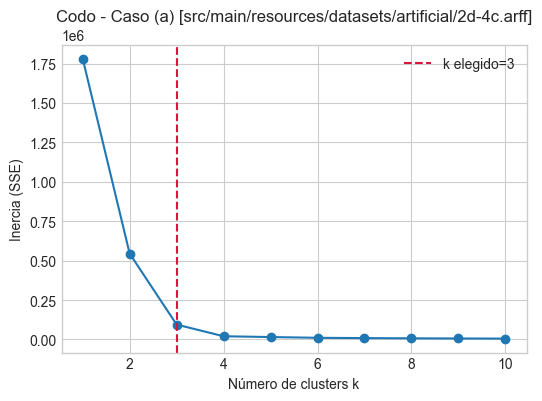

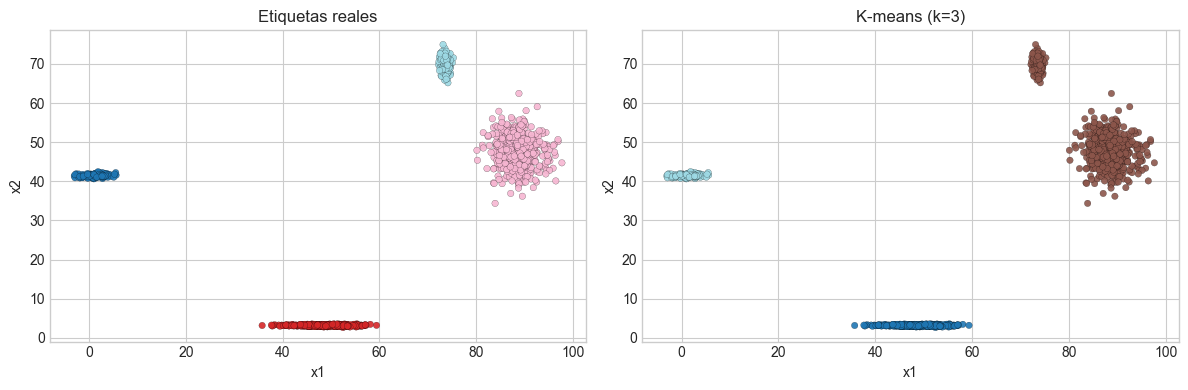

Silhouette (a): 0.8663
ARI vs etiqueta real (a): 0.8293


In [9]:
X_a, y_a, df_a = load_arff_dataset(branch, path_a)
ks_a, inertias_a = elbow_inertia(X_a, k_min=1, k_max=10)
k_a = choose_k_by_knee(ks_a, inertias_a)
plot_elbow(ks_a, inertias_a, k_a, f'Codo - Caso (a) [{path_a}]')

model_a, labels_a = fit_kmeans(X_a, k_a)
sil_a = silhouette_score(X_a, labels_a) if len(np.unique(labels_a)) > 1 else np.nan
ari_a = adjusted_rand_score(y_a, labels_a) if y_a is not None else np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if y_a is not None:
    _, y_a_int = np.unique(y_a, return_inverse=True)
    plot_clusters(axes[0], X_a, y_a_int, 'Etiquetas reales', cmap='tab20')
else:
    axes[0].scatter(X_a[:, 0], X_a[:, 1], s=22, c='gray', alpha=0.9)
    axes[0].set_title('Datos (sin etiquetas reales)')
    axes[0].set_xlabel('x1')
    axes[0].set_ylabel('x2')

plot_clusters(axes[1], X_a, labels_a, f'K-means (k={k_a})', cmap='tab20')
plt.tight_layout()
plt.show()

print(f'Silhouette (a): {sil_a:.4f}')
if not np.isnan(ari_a):
    print(f'ARI vs etiqueta real (a): {ari_a:.4f}')

**Comentario (a):** en datasets con grupos aproximadamente esféricos y bien separados, K-means suele recuperar bien la estructura.

## Caso (b): linealmente separable pero K-means no funciona bien (`2d-4c-no9.arff`)

Además se prueba si puede mejorarse al escalar un atributo: $x_2' = f dot x_2$.

C:\Users\usuario\AppData\Local\Temp\ipykernel_12412\3220811613.py:20: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


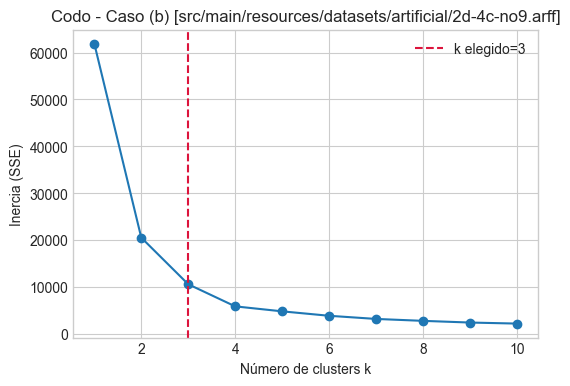

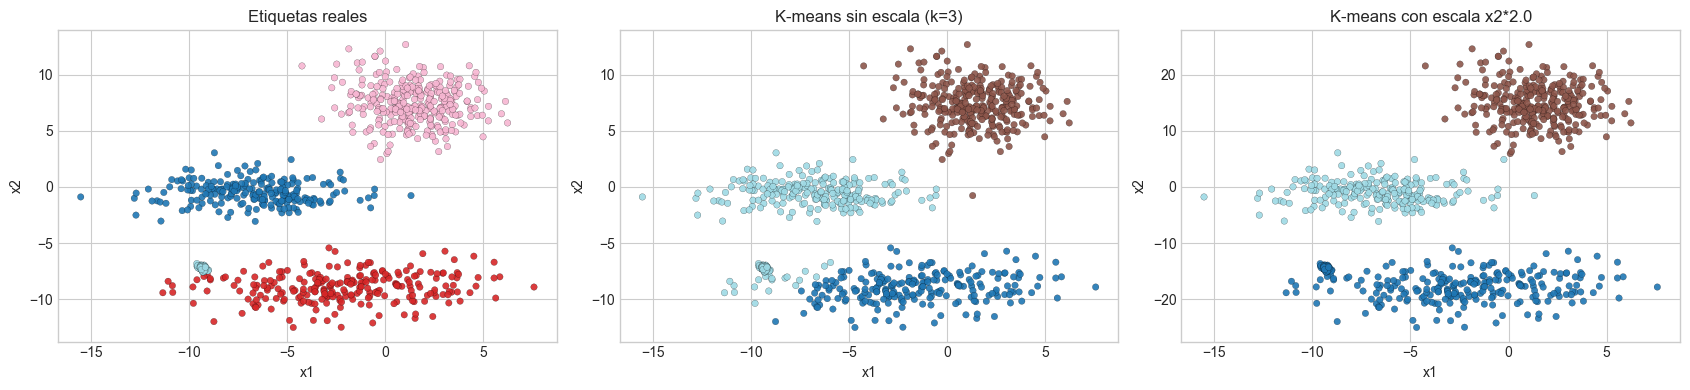

Sin escala -> silhouette=0.5936, ARI=0.7974
Con escala  -> silhouette=0.6858, ARI=0.8476
Top factores probados (factor, silhouette, ARI, score):
(2.0, 0.6858387108315641, 0.8475765699626343, 0.8475765699626343)
(3.0, 0.726057300046222, 0.8443422152329602, 0.8443422152329602)
(5.0, 0.7582536998116278, 0.8379077917088679, 0.8379077917088679)
(10.0, 0.7796630882702623, 0.8379077917088679, 0.8379077917088679)
(1.0, 0.5936466818932, 0.7974291742301026, 0.7974291742301026)


In [10]:
X_b, y_b, df_b = load_arff_dataset(branch, path_b)

ks_b, inertias_b = elbow_inertia(X_b, k_min=1, k_max=10)
k_b = choose_k_by_knee(ks_b, inertias_b)
plot_elbow(ks_b, inertias_b, k_b, f'Codo - Caso (b) [{path_b}]')

model_b, labels_b = fit_kmeans(X_b, k_b)
sil_b = silhouette_score(X_b, labels_b) if len(np.unique(labels_b)) > 1 else np.nan
ari_b = adjusted_rand_score(y_b, labels_b) if y_b is not None else np.nan

# Búsqueda simple de factor de escala en x2
factors = [0.1, 0.2, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]
results_scale = []
for f in factors:
    X_tmp = X_b.copy()
    X_tmp[:, 1] = X_tmp[:, 1] * f
    _, lab_tmp = fit_kmeans(X_tmp, k_b)
    sil_tmp = silhouette_score(X_tmp, lab_tmp) if len(np.unique(lab_tmp)) > 1 else np.nan
    ari_tmp = adjusted_rand_score(y_b, lab_tmp) if y_b is not None else np.nan
    score = ari_tmp if not np.isnan(ari_tmp) else sil_tmp
    results_scale.append((f, sil_tmp, ari_tmp, score))

results_scale = sorted(results_scale, key=lambda t: t[3], reverse=True)
best_factor = results_scale[0][0]

X_b_scaled = X_b.copy()
X_b_scaled[:, 1] = X_b_scaled[:, 1] * best_factor
model_bs, labels_bs = fit_kmeans(X_b_scaled, k_b)
sil_bs = silhouette_score(X_b_scaled, labels_bs) if len(np.unique(labels_bs)) > 1 else np.nan
ari_bs = adjusted_rand_score(y_b, labels_bs) if y_b is not None else np.nan

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
if y_b is not None:
    _, y_b_int = np.unique(y_b, return_inverse=True)
    plot_clusters(axes[0], X_b, y_b_int, 'Etiquetas reales', cmap='tab20')
else:
    axes[0].scatter(X_b[:, 0], X_b[:, 1], s=22, c='gray', alpha=0.9)
    axes[0].set_title('Datos (sin etiquetas)')
    axes[0].set_xlabel('x1')
    axes[0].set_ylabel('x2')

plot_clusters(axes[1], X_b, labels_b, f'K-means sin escala (k={k_b})', cmap='tab20')
plot_clusters(axes[2], X_b_scaled, labels_bs, f'K-means con escala x2*{best_factor}', cmap='tab20')
plt.tight_layout()
plt.show()

print(f'Sin escala -> silhouette={sil_b:.4f}', end='')
if not np.isnan(ari_b):
    print(f', ARI={ari_b:.4f}')
else:
    print()

print(f'Con escala  -> silhouette={sil_bs:.4f}', end='')
if not np.isnan(ari_bs):
    print(f', ARI={ari_bs:.4f}')
else:
    print()

print('Top factores probados (factor, silhouette, ARI, score):')
for row in results_scale[:5]:
    print(row)

**Comentario (b):** aunque los grupos puedan verse separables visualmente, K-means minimiza distancias euclídeas a centroides y asume formas aproximadamente convexas/esféricas. Escalar un atributo puede cambiar la geometría y mejorar (o empeorar) la partición.

## Caso (c): no linealmente separable (K-means no funciona bien)

C:\Users\usuario\AppData\Local\Temp\ipykernel_12412\3220811613.py:20: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


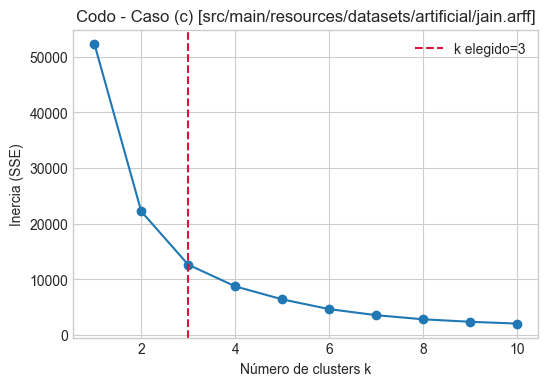

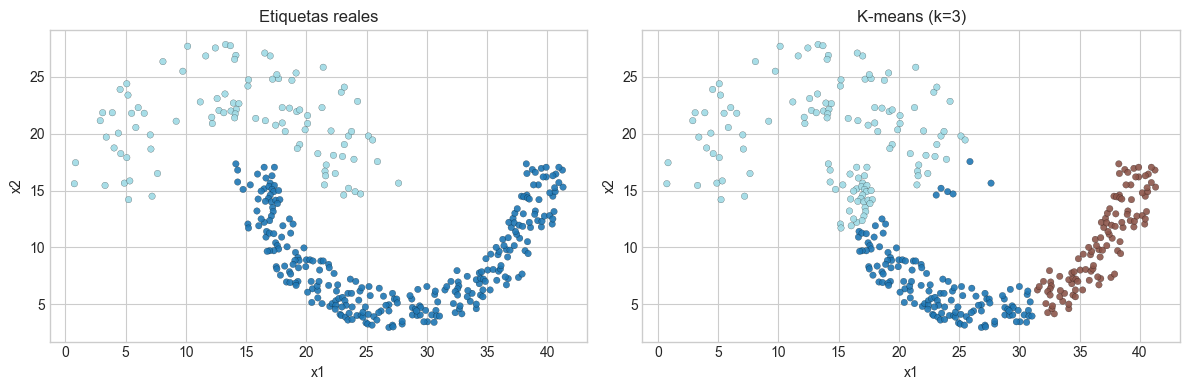

Silhouette (c): 0.4866
ARI vs etiqueta real (c): 0.2625


In [11]:
X_c, y_c, df_c = load_arff_dataset(branch, path_c)
ks_c, inertias_c = elbow_inertia(X_c, k_min=1, k_max=10)
k_c = choose_k_by_knee(ks_c, inertias_c)
plot_elbow(ks_c, inertias_c, k_c, f'Codo - Caso (c) [{path_c}]')

model_c, labels_c = fit_kmeans(X_c, k_c)
sil_c = silhouette_score(X_c, labels_c) if len(np.unique(labels_c)) > 1 else np.nan
ari_c = adjusted_rand_score(y_c, labels_c) if y_c is not None else np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if y_c is not None:
    _, y_c_int = np.unique(y_c, return_inverse=True)
    plot_clusters(axes[0], X_c, y_c_int, 'Etiquetas reales', cmap='tab20')
else:
    axes[0].scatter(X_c[:, 0], X_c[:, 1], s=22, c='gray', alpha=0.9)
    axes[0].set_title('Datos (sin etiquetas reales)')
    axes[0].set_xlabel('x1')
    axes[0].set_ylabel('x2')

plot_clusters(axes[1], X_c, labels_c, f'K-means (k={k_c})', cmap='tab20')
plt.tight_layout()
plt.show()

print(f'Silhouette (c): {sil_c:.4f}')
if not np.isnan(ari_c):
    print(f'ARI vs etiqueta real (c): {ari_c:.4f}')

**Comentario (c):** en estructuras no convexas/no lineales (anillos, espirales, etc.), K-means suele partir regiones por proximidad al centroide y no respeta la forma real de los clusters.

## Conclusión breve

- El **método del codo** sirve para estimar $k$, pero no garantiza un clustering correcto.
- K-means funciona mejor con clusters **compactos y convexos**.
- Un **escalado de atributos** puede mejorar casos concretos (como `2d-4c-no9.arff`) al modificar la métrica efectiva.
- Para clusters no lineales, suelen funcionar mejor métodos como DBSCAN o spectral clustering.